In [13]:
import pandas as pd 
import numpy as np

In [3]:
df = pd.read_csv("/kaggle/input/datasets/maso0dahmed/football-players-data/fifa_players.csv")

In [8]:
print(df.info())
print(df.isnull().sum())
print(df.shape)
print(df.columns)

           name                       full_name birth_date  age  height_cm  \
0      L. Messi  Lionel Andrés Messi Cuccittini  6/24/1987   31     170.18   
1    C. Eriksen    Christian  Dannemann Eriksen  2/14/1992   27     154.94   
2      P. Pogba                      Paul Pogba  3/15/1993   25     190.50   
3    L. Insigne                 Lorenzo Insigne   6/4/1991   27     162.56   
4  K. Koulibaly               Kalidou Koulibaly  6/20/1991   27     187.96   

   weight_kgs  positions nationality  overall_rating  potential  ...  \
0        72.1   CF,RW,ST   Argentina              94         94  ...   
1        76.2  CAM,RM,CM     Denmark              88         89  ...   
2        83.9     CM,CAM      France              88         91  ...   
3        59.0      LW,ST       Italy              88         88  ...   
4        88.9         CB     Senegal              88         91  ...   

   long_shots  aggression interceptions  positioning  vision  penalties  \
0          94          

In [9]:
# Football skill attributes to be considered for clustering
clustering_features = [
    "crossing",
    "finishing",
    "heading_accuracy",
    "short_passing",
    "volleys",
    "dribbling",
    "curve",
    "freekick_accuracy",
    "long_passing",
    "ball_control",
    "acceleration",
    "sprint_speed",
    "agility",
    "reactions",
    "balance",
    "shot_power",
    "jumping",
    "stamina",
    "strength",
    "long_shots",
    "aggression",
    "interceptions",
    "positioning",
    "vision",
    "penalties",
    "composure",
    "marking",
    "standing_tackle",
    "sliding_tackle"
]

# Check missing values
missing_summary = df[clustering_features].isnull().sum()

print("Missing values in clustering features:")
print(missing_summary)

print("\nTotal missing values:", missing_summary.sum())

Missing values in clustering features:
crossing             0
finishing            0
heading_accuracy     0
short_passing        0
volleys              0
dribbling            0
curve                0
freekick_accuracy    0
long_passing         0
ball_control         0
acceleration         0
sprint_speed         0
agility              0
reactions            0
balance              0
shot_power           0
jumping              0
stamina              0
strength             0
long_shots           0
aggression           0
interceptions        0
positioning          0
vision               0
penalties            0
composure            0
marking              0
standing_tackle      0
sliding_tackle       0
dtype: int64

Total missing values: 0


In [10]:
import matplotlib.pyplot as plt

# Summary statistics for clustering features
feature_summary = df[clustering_features].describe().T

print(feature_summary)

                     count       mean        std   min   25%   50%   75%   max
crossing           17954.0  49.697672  18.483310   5.0  38.0  54.0  64.0  93.0
finishing          17954.0  45.358249  19.640792   2.0  30.0  49.0  62.0  95.0
heading_accuracy   17954.0  52.148212  17.521819   4.0  44.0  56.0  64.0  94.0
short_passing      17954.0  58.566058  14.863178   7.0  53.0  62.0  68.0  93.0
volleys            17954.0  42.755208  17.802936   3.0  30.0  44.0  57.0  90.0
dribbling          17954.0  55.278991  19.091876   4.0  49.0  61.0  68.0  97.0
curve              17954.0  47.101147  18.536621   6.0  34.0  49.0  62.0  94.0
freekick_accuracy  17954.0  42.688092  17.565634   3.0  30.0  41.0  56.0  94.0
long_passing       17954.0  52.667428  15.421545   9.0  43.0  56.0  64.0  93.0
ball_control       17954.0  58.223906  16.875717   5.0  54.0  63.0  69.0  96.0
acceleration       17954.0  64.696224  15.001345  12.0  57.0  67.0  75.0  97.0
sprint_speed       17954.0  64.803498  14.722750  12

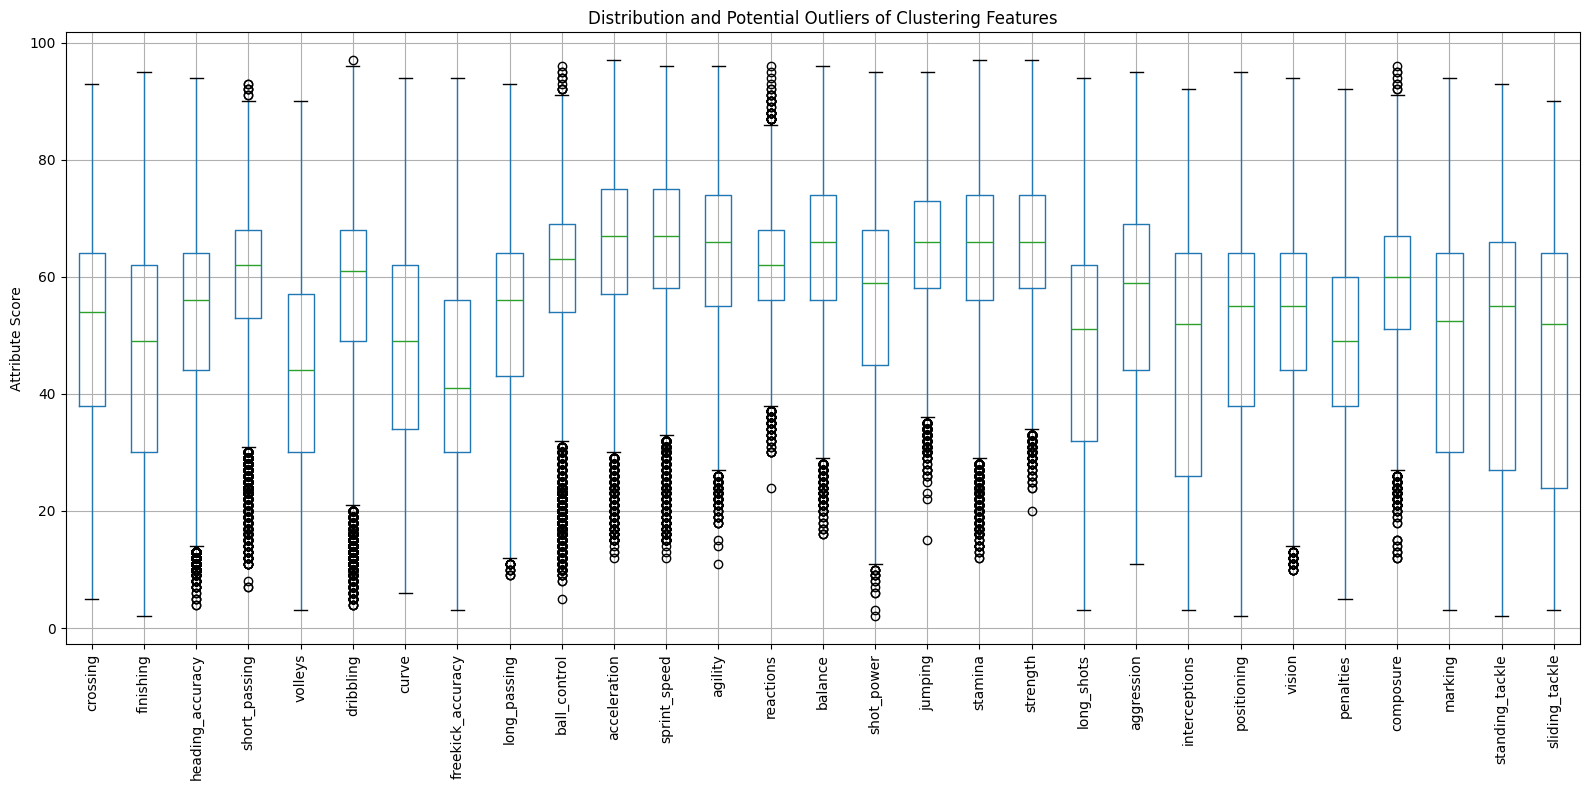

In [11]:
# Boxplots to inspect spread and potential outliers
plt.figure(figsize=(16, 8))

df[clustering_features].boxplot(rot=90)

plt.title("Distribution and Potential Outliers of Clustering Features")
plt.ylabel("Attribute Score")
plt.tight_layout()
plt.show()

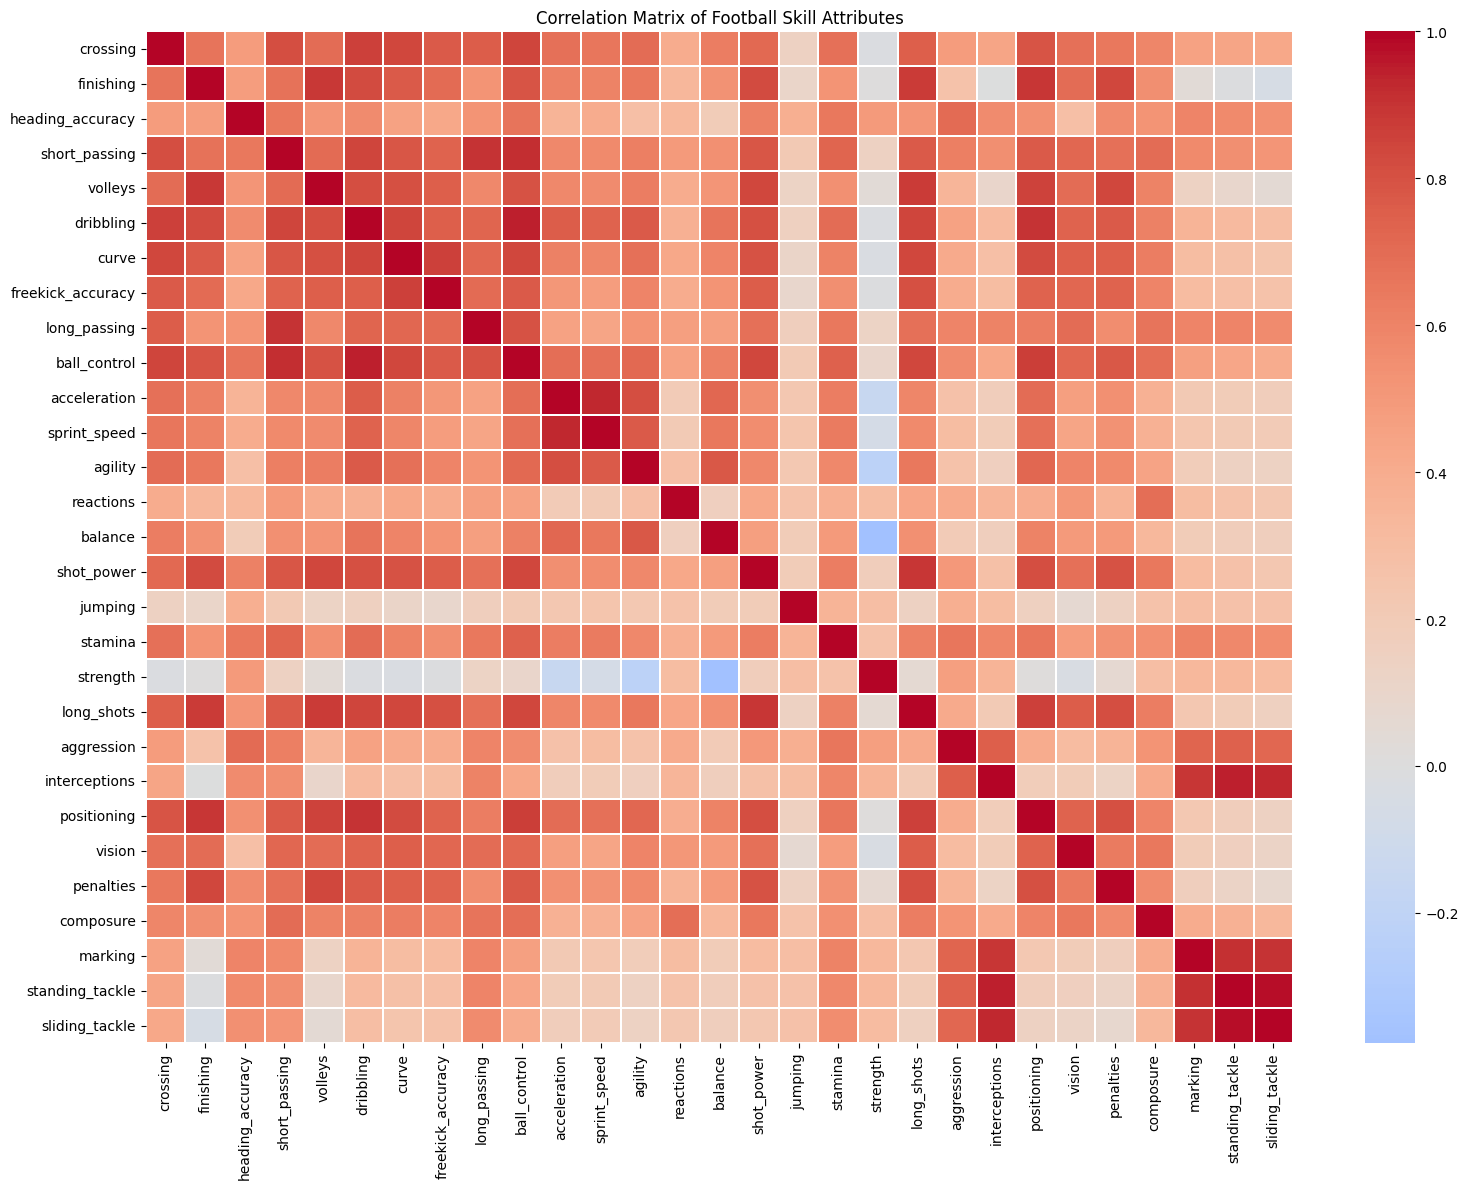

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation matrix
corr_matrix = df[clustering_features].corr()

plt.figure(figsize=(16, 12))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.3
)

plt.title("Correlation Matrix of Football Skill Attributes")
plt.tight_layout()
plt.show()

In [14]:
# Extract upper triangle of correlation matrix
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Find highly correlated feature pairs
high_corr_pairs = (
    upper.stack()
    .reset_index()
)

high_corr_pairs.columns = ["Feature_1", "Feature_2", "Correlation"]

high_corr_pairs = high_corr_pairs[
    high_corr_pairs["Correlation"].abs() >= 0.70
].sort_values(
    "Correlation",
    key=abs,
    ascending=False
)

print(high_corr_pairs.to_string(index=False))

        Feature_1         Feature_2  Correlation
  standing_tackle    sliding_tackle     0.975138
    interceptions   standing_tackle     0.943150
        dribbling      ball_control     0.941556
    interceptions    sliding_tackle     0.930522
     acceleration      sprint_speed     0.926151
    short_passing      ball_control     0.914922
          marking   standing_tackle     0.911632
        dribbling       positioning     0.901656
          marking    sliding_tackle     0.901460
    short_passing      long_passing     0.898730
    interceptions           marking     0.895607
       shot_power        long_shots     0.892452
        finishing       positioning     0.890049
        finishing           volleys     0.886469
        finishing        long_shots     0.880080
          volleys        long_shots     0.871201
     ball_control       positioning     0.869492
       long_shots       positioning     0.863814
            curve freekick_accuracy     0.862054
         crossing   

In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Select clustering features
X = df[clustering_features]

# Standardize each feature
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Original shape:", X.shape)
print("Scaled shape:", X_scaled.shape)

Original shape: (17954, 29)
Scaled shape: (17954, 29)


In [16]:
# Fit PCA while retaining all components
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Explained variance of each component
explained_variance = pca.explained_variance_ratio_

print("Number of components:", pca.n_components_)
print("Total explained variance:", explained_variance.sum())

Number of components: 29
Total explained variance: 1.0


In [17]:
import numpy as np

cumulative_variance = np.cumsum(explained_variance)

for threshold in [0.90, 0.95, 0.99]:
    n_components = np.argmax(cumulative_variance >= threshold) + 1
    print(f"{threshold*100:.0f}% variance → {n_components} components")

90% variance → 8 components
95% variance → 15 components
99% variance → 24 components


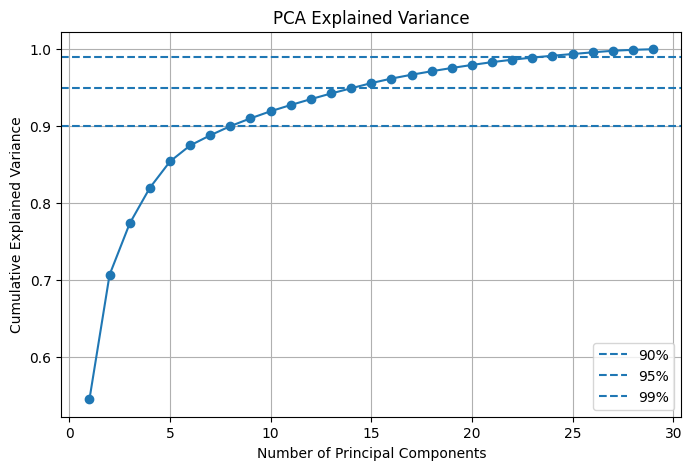

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.axhline(0.90, linestyle="--", label="90%")
plt.axhline(0.95, linestyle="--", label="95%")
plt.axhline(0.99, linestyle="--", label="99%")

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.legend()
plt.grid()
plt.show()

In [19]:
# PCA loadings
loadings = pd.DataFrame(
    pca.components_.T,
    index=clustering_features,
    columns=[f"PC{i}" for i in range(1, pca.n_components_ + 1)]
)

# Inspect the first 5 principal components
for pc in ["PC1", "PC2", "PC3", "PC4", "PC5"]:
    
    print(f"\n{'='*50}")
    print(f"{pc} - Top positive and negative loadings")
    print(f"{'='*50}")
    
    pc_loadings = loadings[pc].sort_values()
    
    print("\nMost negative:")
    print(pc_loadings.head(5))
    
    print("\nMost positive:")
    print(pc_loadings.tail(5))


PC1 - Top positive and negative loadings

Most negative:
strength           0.032876
jumping            0.069549
sliding_tackle     0.113261
standing_tackle    0.121387
interceptions      0.123611
Name: PC1, dtype: float64

Most positive:
crossing         0.222727
positioning      0.223067
short_passing    0.232108
dribbling        0.234762
ball_control     0.240795
Name: PC1, dtype: float64

PC2 - Top positive and negative loadings

Most negative:
finishing     -0.208679
volleys       -0.160781
agility       -0.147196
positioning   -0.136073
penalties     -0.134637
Name: PC2, dtype: float64

Most positive:
aggression         0.280922
marking            0.352983
interceptions      0.372151
standing_tackle    0.375384
sliding_tackle     0.377142
Name: PC2, dtype: float64

PC3 - Top positive and negative loadings

Most negative:
balance          -0.372601
acceleration     -0.332686
sprint_speed     -0.300136
agility          -0.270534
sliding_tackle   -0.172482
Name: PC3, dtype: float64

In [20]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Range of cluster numbers to evaluate
k_values = range(2, 11)

inertias = []
silhouette_scores = []

for k in k_values:
    
    # Fit K-Means
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    cluster_labels = kmeans.fit_predict(X_scaled)
    
    # Store metrics
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(
        silhouette_score(X_scaled, cluster_labels)
    )

# Display results
for k, inertia, silhouette in zip(
    k_values, inertias, silhouette_scores
):
    print(
        f"K={k}: "
        f"Inertia={inertia:.2f}, "
        f"Silhouette={silhouette:.4f}"
    )

K=2: Inertia=326371.26, Silhouette=0.4585
K=3: Inertia=253195.87, Silhouette=0.2526
K=4: Inertia=211563.53, Silhouette=0.2492
K=5: Inertia=192990.04, Silhouette=0.2254
K=6: Inertia=180889.51, Silhouette=0.1978
K=7: Inertia=171780.70, Silhouette=0.1957
K=8: Inertia=163481.94, Silhouette=0.1902
K=9: Inertia=157925.61, Silhouette=0.1794
K=10: Inertia=152875.36, Silhouette=0.1468


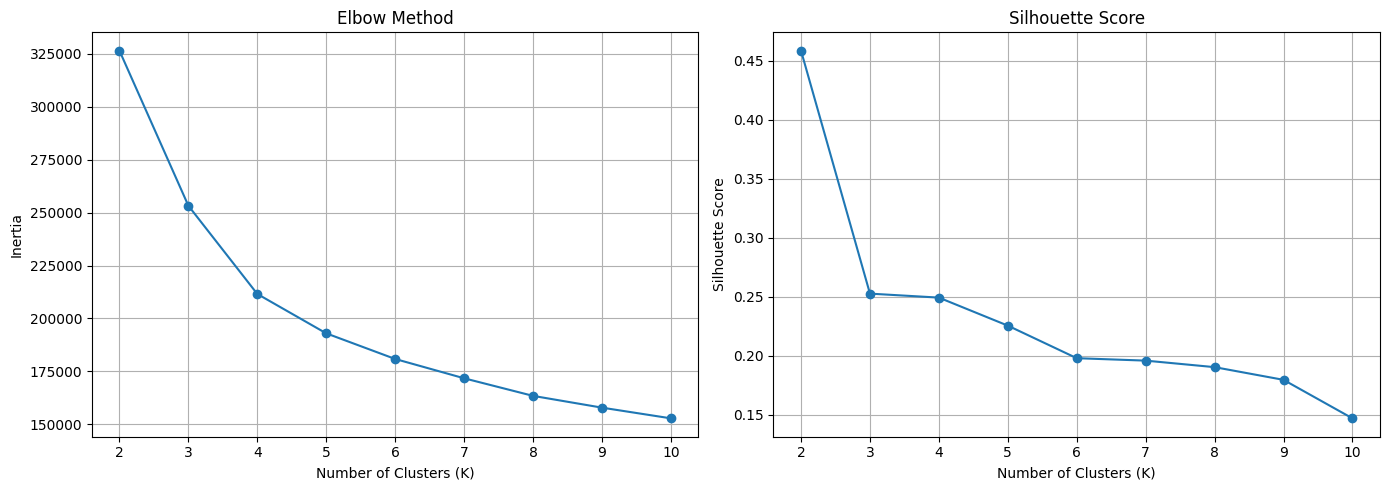

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
axes[0].plot(k_values, inertias, marker="o")
axes[0].set_xlabel("Number of Clusters (K)")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow Method")
axes[0].grid()

# Silhouette plot
axes[1].plot(k_values, silhouette_scores, marker="o")
axes[1].set_xlabel("Number of Clusters (K)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score")
axes[1].grid()

plt.tight_layout()
plt.show()


In [22]:
# PCA retaining 90% variance
pca_90 = PCA(n_components=8)
X_pca_90 = pca_90.fit_transform(X_scaled)

# PCA retaining 95% variance
pca_95 = PCA(n_components=15)
X_pca_95 = pca_95.fit_transform(X_scaled)

print("Original features:", X_scaled.shape[1])
print("PCA 90% features:", X_pca_90.shape[1])
print("PCA 95% features:", X_pca_95.shape[1])

Original features: 29
PCA 90% features: 8
PCA 95% features: 15


In [23]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_values = range(2, 11)

results_pca_90 = []
results_pca_95 = []

for k in k_values:

    # ----- PCA 90% -----
    kmeans_90 = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels_90 = kmeans_90.fit_predict(X_pca_90)

    results_pca_90.append({
        "K": k,
        "Inertia": kmeans_90.inertia_,
        "Silhouette": silhouette_score(X_pca_90, labels_90)
    })

    # ----- PCA 95% -----
    kmeans_95 = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels_95 = kmeans_95.fit_predict(X_pca_95)

    results_pca_95.append({
        "K": k,
        "Inertia": kmeans_95.inertia_,
        "Silhouette": silhouette_score(X_pca_95, labels_95)
    })

In [24]:
results_pca_90 = pd.DataFrame(results_pca_90)
results_pca_95 = pd.DataFrame(results_pca_95)

print("PCA 90% RESULTS")
display(results_pca_90)

print("\nPCA 95% RESULTS")
display(results_pca_95)

PCA 90% RESULTS


,K,Inertia,Silhouette
0,2,274360.324324,0.497691
1,3,201249.073623,0.294153
2,4,159781.485781,0.298015
3,5,141403.244897,0.275144
4,6,129405.812873,0.248196
5,7,120374.318731,0.247725
6,8,112336.331423,0.243259
7,9,107061.828108,0.231529
8,10,102189.125600,0.199133



PCA 95% RESULTS


,K,Inertia,Silhouette
0,2,303454.041615,0.474976
1,3,230297.097615,0.268721
2,4,188696.472291,0.268205
3,5,170187.321378,0.244660
4,6,158105.949952,0.217158
5,7,149002.664808,0.214849
6,8,140738.728120,0.210011
7,9,135252.135612,0.199302
8,10,130214.874833,0.166542


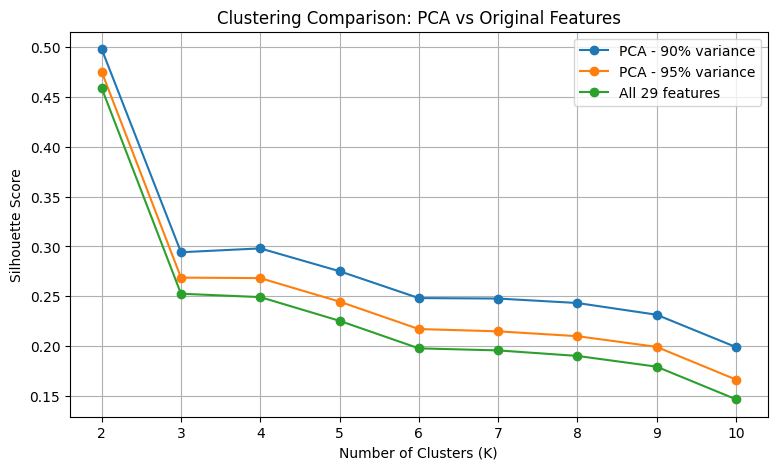

In [25]:
plt.figure(figsize=(9, 5))

plt.plot(
    results_pca_90["K"],
    results_pca_90["Silhouette"],
    marker="o",
    label="PCA - 90% variance"
)

plt.plot(
    results_pca_95["K"],
    results_pca_95["Silhouette"],
    marker="o",
    label="PCA - 95% variance"
)

plt.plot(
    k_values,
    silhouette_scores,
    marker="o",
    label="All 29 features"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Clustering Comparison: PCA vs Original Features")
plt.legend()
plt.grid()
plt.show()

In [26]:
# Fit K-Means for K = 2, 3, 4 using PCA-8
cluster_models = {}

for k in [2, 3, 4]:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = model.fit_predict(X_pca_90)
    cluster_models[k] = labels

In [27]:
# Create a dataframe for cluster analysis
cluster_df = df.copy()

# Add cluster labels
for k, labels in cluster_models.items():
    cluster_df[f"cluster_k{k}"] = labels



In [28]:
for k in [2, 3, 4]:
    print(f"\nK = {k}")
    print(
        cluster_df[f"cluster_k{k}"]
        .value_counts()
        .sort_index()
    )


K = 2
cluster_k2
0    15610
1     2344
Name: count, dtype: int64

K = 3
cluster_k3
0    6503
1    2073
2    9378
Name: count, dtype: int64

K = 4
cluster_k4
0    5149
1    2071
2    5233
3    5501
Name: count, dtype: int64


In [29]:
for k in [2, 3, 4]:
    
    print(f"\n{'='*60}")
    print(f"K = {k}")
    print(f"{'='*60}")
    
    profile = (
        cluster_df
        .groupby(f"cluster_k{k}")[
            ["overall_rating", "potential", "age", "value_euro"]
        ]
        .mean()
        .round(2)
    )
    
    print(profile)


K = 2
            overall_rating  potential    age  value_euro
cluster_k2                                              
0                    66.66      71.74  25.51  2632696.43
1                    63.43      69.38  25.93  1451611.57

K = 3
            overall_rating  potential    age  value_euro
cluster_k3                                              
0                    63.11      69.80  24.48  1153578.55
1                    64.44      69.80  26.45  1620765.26
2                    68.80      72.92  26.13  3587290.56

K = 4
            overall_rating  potential    age  value_euro
cluster_k4                                              
0                    64.06      70.89  23.98  1285677.22
1                    64.45      69.81  26.44  1622327.59
2                    63.68      69.88  24.79  1121676.36
3                    71.39      74.02  27.45  5209719.82


In [30]:
from scipy.stats import kruskal

# Overall rating by K=4 clusters
rating_groups = [
    group["overall_rating"].values
    for _, group in cluster_df.groupby("cluster_k4")
]

stat, p_value = kruskal(*rating_groups)

print(f"Kruskal-Wallis statistic: {stat:.4f}")
print(f"p-value: {p_value:.4e}")

Kruskal-Wallis statistic: 4536.9518
p-value: 0.0000e+00


<Figure size 800x500 with 0 Axes>

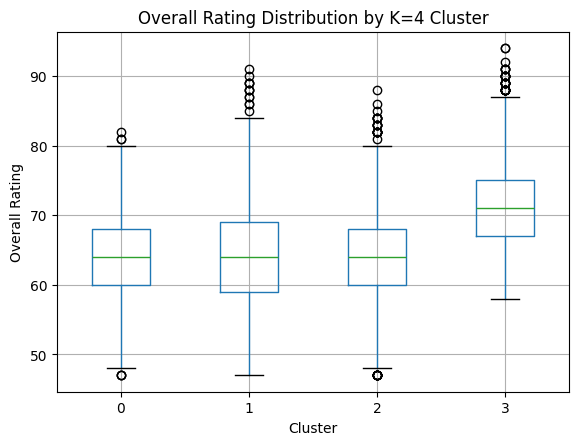

In [31]:
plt.figure(figsize=(8, 5))

cluster_df.boxplot(
    column="overall_rating",
    by="cluster_k4"
)

plt.title("Overall Rating Distribution by K=4 Cluster")
plt.suptitle("")
plt.xlabel("Cluster")
plt.ylabel("Overall Rating")

plt.show()

In [34]:
import scikit_posthocs as sp

# Dunn's post-hoc test
dunn_results = sp.posthoc_dunn(
    cluster_df,
    val_col="overall_rating",
    group_col="cluster_k4",
    p_adjust="bonferroni"
)

print(dunn_results)

          0         1         2    3
0  1.000000  0.039504  0.020444  0.0
1  0.039504  1.000000  0.000005  0.0
2  0.020444  0.000005  1.000000  0.0
3  0.000000  0.000000  0.000000  1.0


In [35]:
# Mean football attributes for each cluster
cluster_attribute_means = (
    cluster_df
    .groupby("cluster_k4")[clustering_features]
    .mean()
    .round(2)
)

display(cluster_attribute_means)

,crossing,finishing,heading_accuracy,short_passing,volleys,dribbling,curve,freekick_accuracy,long_passing,ball_control,...,long_shots,aggression,interceptions,positioning,vision,penalties,composure,marking,standing_tackle,sliding_tackle
cluster_k4,,,,,,,,,,,,,,,,,,,,,
0,52.29,60.50,52.66,59.80,53.17,64.35,52.95,46.25,50.39,63.97,...,55.81,47.45,28.89,60.94,56.73,57.56,58.01,32.77,30.17,28.42
1,14.26,11.92,14.37,27.16,12.28,13.77,14.62,14.37,25.76,19.88,...,12.46,26.26,16.94,11.14,37.12,19.90,44.47,15.02,14.16,14.06
2,45.11,31.84,59.43,57.08,32.02,48.75,37.41,34.48,51.25,54.58,...,35.05,63.61,60.99,39.84,43.54,40.75,54.98,61.10,64.06,62.05
3,64.97,56.63,58.96,70.64,54.69,68.63,63.07,57.82,66.28,70.75,...,62.65,67.37,60.84,63.59,65.81,57.70,68.17,59.48,61.28,58.25


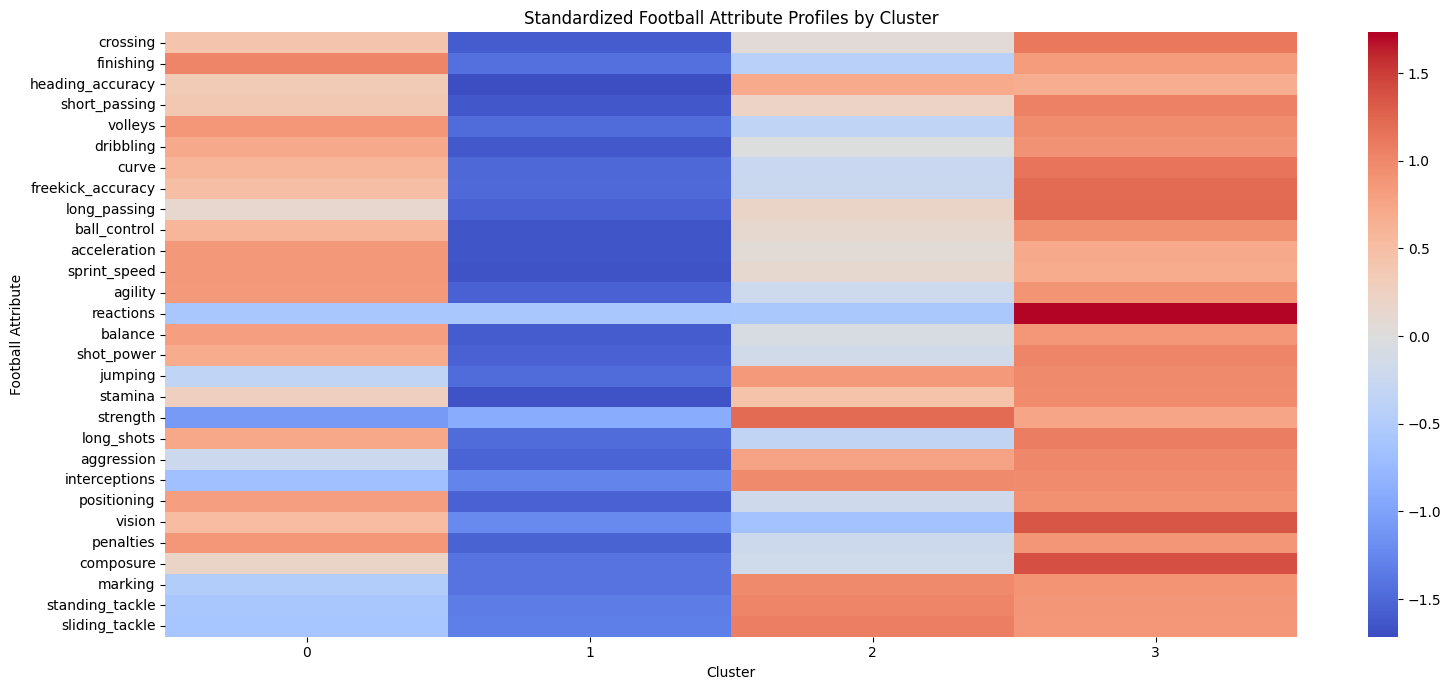

In [36]:
# Standardized cluster profiles
from scipy.stats import zscore

cluster_profile_z = cluster_attribute_means.apply(
    zscore,
    axis=0
)

plt.figure(figsize=(16, 7))

sns.heatmap(
    cluster_profile_z.T,
    center=0,
    cmap="coolwarm",
    annot=False
)

plt.title("Standardized Football Attribute Profiles by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Football Attribute")

plt.tight_layout()
plt.show()

In [37]:
# Standardize cluster means to identify distinguishing attributes
cluster_profile_z = cluster_attribute_means.apply(
    lambda x: (x - x.mean()) / x.std(),
    axis=0
)

# Top distinguishing attributes for each cluster
for cluster in cluster_profile_z.index:
    print(f"\n{'='*50}")
    print(f"Cluster {cluster}")
    print(f"{'='*50}")
    
    print(
        cluster_profile_z.loc[cluster]
        .sort_values(ascending=False)
        .head(8)
    )


Cluster 0
finishing       0.891608
penalties       0.758127
volleys         0.754629
acceleration    0.753221
sprint_speed    0.743643
agility         0.732237
positioning     0.702898
balance         0.701980
Name: 0, dtype: float64

Cluster 1
reactions         -0.509861
strength          -0.776414
vision            -1.059315
interceptions     -1.111222
sliding_tackle    -1.144665
standing_tackle   -1.162463
marking           -1.217458
composure         -1.223761
Name: 1, dtype: float64

Cluster 2
strength            1.055027
sliding_tackle      0.917752
standing_tackle     0.890334
marking             0.854773
interceptions       0.848711
jumping             0.735792
aggression          0.664325
heading_accuracy    0.606853
Name: 2, dtype: float64

Cluster 3
reactions            1.499939
composure            1.205821
vision               1.162304
long_passing         1.064589
freekick_accuracy    1.056503
curve                0.998379
crossing             0.965480
long_shots        

In [38]:
# Extract the primary (first-listed) position
cluster_df["primary_position"] = (
    cluster_df["positions"]
    .str.split(",")
    .str[0]
)

# Position distribution within each cluster
position_distribution = pd.crosstab(
    cluster_df["cluster_k4"],
    cluster_df["primary_position"],
    normalize="index"
) * 100

position_distribution = position_distribution.round(2)

display(position_distribution)

primary_position,CAM,CB,CDM,CF,CM,GK,LB,LM,LW,LWB,RB,RM,RW,RWB,ST
cluster_k4,,,,,,,,,,,,,,,
0,11.85,0.00,0.14,1.13,6.95,0.00,0.43,13.46,5.48,0.08,0.39,13.87,5.19,0.10,40.96
1,0.00,0.24,0.00,0.00,0.00,99.71,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.05
2,0.25,52.84,10.30,0.00,7.66,0.00,12.77,0.48,0.02,0.52,13.80,0.48,0.04,0.57,0.29
3,7.69,5.71,15.27,0.55,25.38,0.00,11.53,5.65,1.73,0.62,10.91,5.69,1.58,0.60,7.11


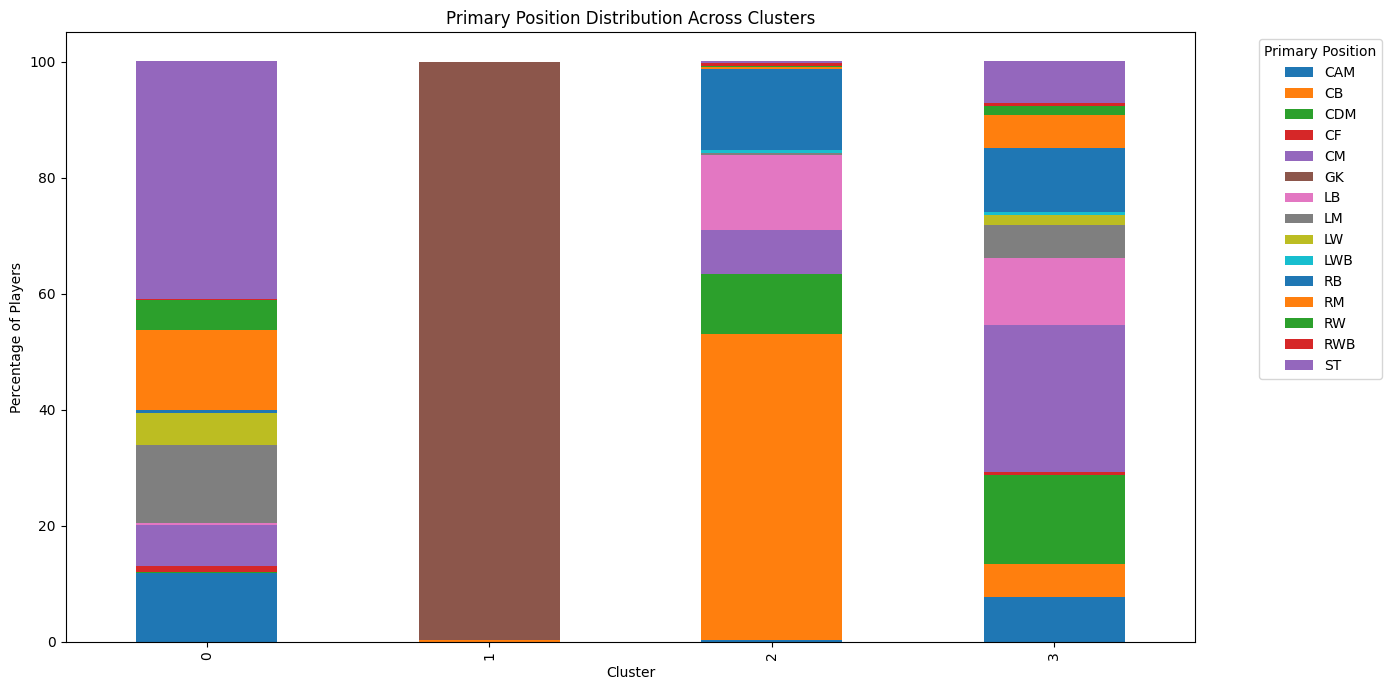

In [39]:
# Plot position composition of each cluster
position_distribution.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 7)
)

plt.title("Primary Position Distribution Across Clusters")
plt.xlabel("Cluster")
plt.ylabel("Percentage of Players")
plt.legend(
    title="Primary Position",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [40]:
# Separate goalkeepers from outfield players
outfield_df = cluster_df[
    cluster_df["primary_position"] != "GK"
].copy()

print("Original players:", len(cluster_df))
print("Outfield players:", len(outfield_df))
print("Goalkeepers:", len(cluster_df) - len(outfield_df))

Original players: 17954
Outfield players: 15889
Goalkeepers: 2065


In [41]:
print("\nOutfield position distribution:")
print(
    outfield_df["primary_position"]
    .value_counts()
    .sort_index()
)


Outfield position distribution:
primary_position
CAM    1046
CB     3084
CDM    1386
CF       88
CM     2155
LB     1324
LM     1029
LW      378
LWB      65
RB     1342
RM     1052
RW      356
RWB      68
ST     2516
Name: count, dtype: int64


In [42]:
# Outfield clustering features
X_outfield = outfield_df[clustering_features]

# Standardize using only outfield players
scaler_outfield = StandardScaler()
X_outfield_scaled = scaler_outfield.fit_transform(X_outfield)

# PCA retaining 90% variance
pca_outfield = PCA(n_components=0.90)
X_outfield_pca = pca_outfield.fit_transform(X_outfield_scaled)

print("Original features:", X_outfield_scaled.shape[1])
print("PCA components:", X_outfield_pca.shape[1])
print(
    "Explained variance:",
    pca_outfield.explained_variance_ratio_.sum()
)

Original features: 29
PCA components: 12
Explained variance: 0.904067415657942


In [43]:
# Number of components for different variance thresholds
pca_full_outfield = PCA()
pca_full_outfield.fit(X_outfield_scaled)

cumulative_variance = np.cumsum(
    pca_full_outfield.explained_variance_ratio_
)

for threshold in [0.90, 0.95, 0.99]:
    n_components = np.argmax(
        cumulative_variance >= threshold
    ) + 1
    
    print(
        f"{threshold*100:.0f}% variance → "
        f"{n_components} components"
    )

90% variance → 12 components
95% variance → 18 components
99% variance → 26 components


In [44]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_values = range(2, 11)

outfield_inertias = []
outfield_silhouettes = []

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_outfield_pca)

    outfield_inertias.append(kmeans.inertia_)
    outfield_silhouettes.append(
        silhouette_score(X_outfield_pca, labels)
    )

# Results
for k, inertia, silhouette in zip(
    k_values,
    outfield_inertias,
    outfield_silhouettes
):
    print(
        f"K={k}: "
        f"Inertia={inertia:.2f}, "
        f"Silhouette={silhouette:.4f}"
    )

K=2: Inertia=297723.63, Silhouette=0.2479
K=3: Inertia=241658.16, Silhouette=0.2334
K=4: Inertia=213194.87, Silhouette=0.2043
K=5: Inertia=195041.31, Silhouette=0.1837
K=6: Inertia=182236.25, Silhouette=0.1812
K=7: Inertia=170367.62, Silhouette=0.1780
K=8: Inertia=161718.58, Silhouette=0.1678
K=9: Inertia=154293.06, Silhouette=0.1620
K=10: Inertia=149209.57, Silhouette=0.1573


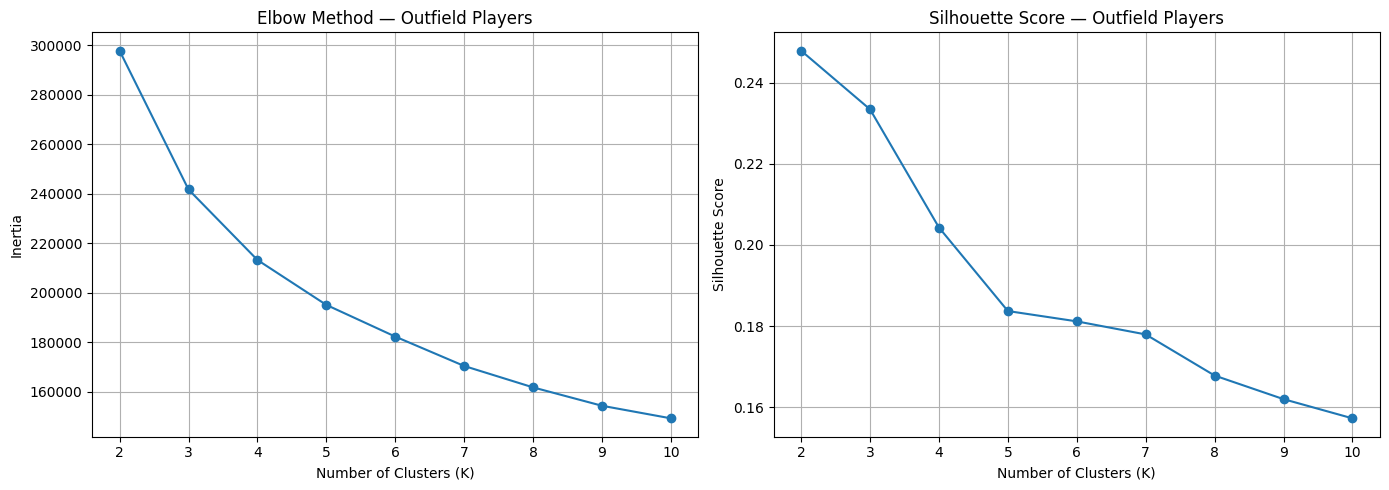

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow
axes[0].plot(
    k_values,
    outfield_inertias,
    marker="o"
)
axes[0].set_xlabel("Number of Clusters (K)")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow Method — Outfield Players")
axes[0].grid()

# Silhouette
axes[1].plot(
    k_values,
    outfield_silhouettes,
    marker="o"
)
axes[1].set_xlabel("Number of Clusters (K)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score — Outfield Players")
axes[1].grid()

plt.tight_layout()
plt.show()

In [46]:
# Fit K=4 for outfield players
kmeans_outfield_4 = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

outfield_labels_4 = kmeans_outfield_4.fit_predict(
    X_outfield_pca
)

outfield_df["cluster_k4"] = outfield_labels_4

# Profile the clusters
outfield_profile = (
    outfield_df
    .groupby("cluster_k4")[
        ["overall_rating", "potential", "age", "value_euro"]
    ]
    .agg(["mean", "median", "count"])
    .round(2)
)

display(outfield_profile)

overall_rating              potential                 age         \
                     mean median count      mean median count   mean median   
cluster_k4                                                                    
0                   73.18   73.0  3577     75.39   75.0  3577  27.63   27.0   
1                   67.86   67.0  4683     71.74   71.0  4683  26.41   26.0   
2                   62.40   63.0  4155     70.17   70.0  4155  23.35   23.0   
3                   62.54   63.0  3474     69.40   69.0  3474  24.42   24.0   

                  value_euro                   
           count        mean     median count  
cluster_k4                                     
0           3577  6903272.78  3900000.0  3523  
1           4683  2206656.56   825000.0  4618  
2           4155   725938.49   500000.0  4113  
3           3474   903668.52   375000.0  3421

In [47]:
from sklearn.neighbors import NearestNeighbors
import numpy as np

def hopkins_statistic(X, sample_size=1000, random_state=42):

    rng = np.random.default_rng(random_state)

    n = X.shape[0]

    # Sample real observations
    sample_indices = rng.choice(
        n,
        size=sample_size,
        replace=False
    )

    X_sample = X[sample_indices]

    # Generate uniformly distributed random points
    X_min = X.min(axis=0)
    X_max = X.max(axis=0)

    X_random = rng.uniform(
        X_min,
        X_max,
        size=(sample_size, X.shape[1])
    )

    # Nearest neighbor distance for real observations
    nn = NearestNeighbors(n_neighbors=2)
    nn.fit(X)

    distances_real, _ = nn.kneighbors(X_sample)

    # Ignore distance to itself
    u = distances_real[:, 1]

    # Nearest neighbor distance for random points
    nn_random = NearestNeighbors(n_neighbors=1)
    nn_random.fit(X)

    distances_random, _ = nn_random.kneighbors(X_random)

    w = distances_random[:, 0]

    # Hopkins statistic
    H = np.sum(w) / (np.sum(w) + np.sum(u))

    return H


H = hopkins_statistic(
    X_scaled,
    sample_size=1000,
    random_state=42
)

print(f"Hopkins Statistic: {H:.4f}")

Hopkins Statistic: 0.7903


In [48]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
import numpy as np

seeds = [0, 10, 20, 30, 40, 50, 100]

cluster_labels = []

for seed in seeds:
    model = KMeans(
        n_clusters=4,
        random_state=seed,
        n_init=10
    )
    
    labels = model.fit_predict(X_pca_90)
    cluster_labels.append(labels)

# Compare every run with the first run
reference = cluster_labels[0]

print("K-Means Stability (Adjusted Rand Index)")
print("=" * 45)

for seed, labels in zip(seeds, cluster_labels):
    ari = adjusted_rand_score(reference, labels)
    print(f"Seed {seed}: ARI = {ari:.4f}")

K-Means Stability (Adjusted Rand Index)
Seed 0: ARI = 1.0000
Seed 10: ARI = 0.9978
Seed 20: ARI = 0.9992
Seed 30: ARI = 0.9990
Seed 40: ARI = 0.9937
Seed 50: ARI = 0.9975
Seed 100: ARI = 0.9995


In [49]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

# Agglomerative clustering
agg_model = AgglomerativeClustering(
    n_clusters=4,
    linkage="ward"
)

agg_labels = agg_model.fit_predict(X_pca_90)

# Evaluation
agg_silhouette = silhouette_score(
    X_pca_90,
    agg_labels
)

agg_calinski = calinski_harabasz_score(
    X_pca_90,
    agg_labels
)

agg_davies = davies_bouldin_score(
    X_pca_90,
    agg_labels
)

print("Agglomerative Clustering (K=4)")
print("=" * 45)
print(f"Silhouette Score:       {agg_silhouette:.4f}")
print(f"Calinski-Harabasz:      {agg_calinski:.2f}")
print(f"Davies-Bouldin:         {agg_davies:.4f}")

print("\nCluster sizes:")
print(
    pd.Series(agg_labels)
    .value_counts()
    .sort_index()
)

Agglomerative Clustering (K=4)
Silhouette Score:       0.2605
Calinski-Harabasz:      9779.15
Davies-Bouldin:         1.2052

Cluster sizes:
0    7900
1    3092
2    4897
3    2065
Name: count, dtype: int64


In [50]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

# GMM with 4 components
gmm_model = GaussianMixture(
    n_components=4,
    covariance_type="full",
    random_state=42,
    n_init=10
)

gmm_labels = gmm_model.fit_predict(X_pca_90)

# Evaluation
gmm_silhouette = silhouette_score(
    X_pca_90,
    gmm_labels
)

gmm_calinski = calinski_harabasz_score(
    X_pca_90,
    gmm_labels
)

gmm_davies = davies_bouldin_score(
    X_pca_90,
    gmm_labels
)

print("Gaussian Mixture Model (K=4)")
print("=" * 45)
print(f"Silhouette Score:       {gmm_silhouette:.4f}")
print(f"Calinski-Harabasz:      {gmm_calinski:.2f}")
print(f"Davies-Bouldin:         {gmm_davies:.4f}")

print("\nCluster sizes:")
print(
    pd.Series(gmm_labels)
    .value_counts()
    .sort_index()
)

Gaussian Mixture Model (K=4)
Silhouette Score:       0.2342
Calinski-Harabasz:      9614.08
Davies-Bouldin:         1.4479

Cluster sizes:
0    5530
1    5099
2    2065
3    5260
Name: count, dtype: int64


In [51]:
# K-Means evaluation for K=4
kmeans_final = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans_final.fit_predict(X_pca_90)

kmeans_silhouette = silhouette_score(
    X_pca_90, kmeans_labels
)

kmeans_calinski = calinski_harabasz_score(
    X_pca_90, kmeans_labels
)

kmeans_davies = davies_bouldin_score(
    X_pca_90, kmeans_labels
)

print("K-Means (K=4)")
print("=" * 45)
print(f"Silhouette Score:       {kmeans_silhouette:.4f}")
print(f"Calinski-Harabasz:      {kmeans_calinski:.2f}")
print(f"Davies-Bouldin:         {kmeans_davies:.4f}")

K-Means (K=4)
Silhouette Score:       0.2980
Calinski-Harabasz:      11565.16
Davies-Bouldin:         1.1633


In [52]:
# Store final K-Means labels
cluster_df["final_cluster"] = kmeans_labels

print(cluster_df["final_cluster"].value_counts().sort_index())

final_cluster
0    5149
1    2071
2    5233
3    5501
Name: count, dtype: int64


In [53]:
# 2D PCA for visualization only
pca_2d = PCA(n_components=2)

X_pca_2d = pca_2d.fit_transform(X_scaled)

print(
    "Variance explained by PC1 + PC2:",
    pca_2d.explained_variance_ratio_.sum()
)

Variance explained by PC1 + PC2: 0.7068819002430538


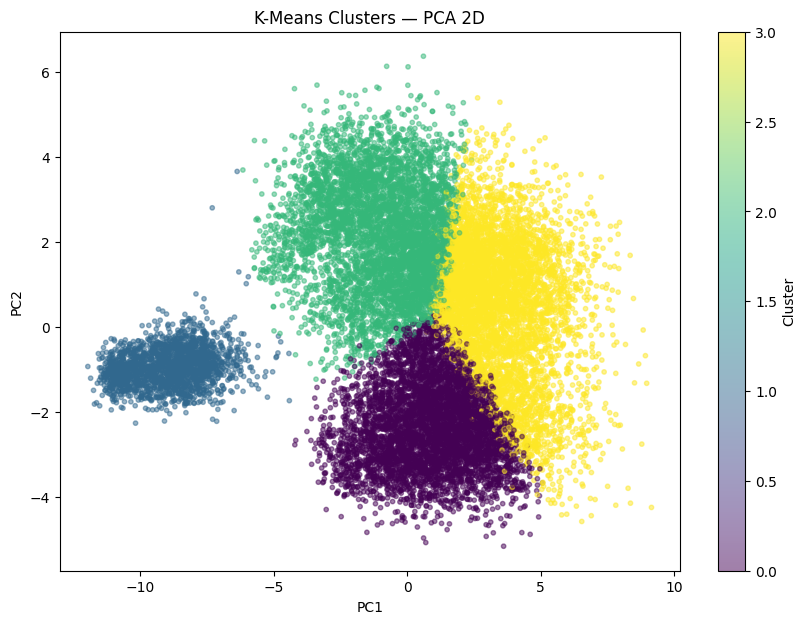

In [54]:
plt.figure(figsize=(10, 7))

plt.scatter(
    X_pca_2d[:, 0],
    X_pca_2d[:, 1],
    c=cluster_df["final_cluster"],
    s=10,
    alpha=0.5
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clusters — PCA 2D")
plt.colorbar(label="Cluster")

plt.show()

In [55]:
from sklearn.manifold import TSNE

# t-SNE for visualization only
tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    init="pca",
    learning_rate="auto"
)

X_tsne = tsne.fit_transform(X_pca_90)

print("t-SNE shape:", X_tsne.shape)

t-SNE shape: (17954, 2)


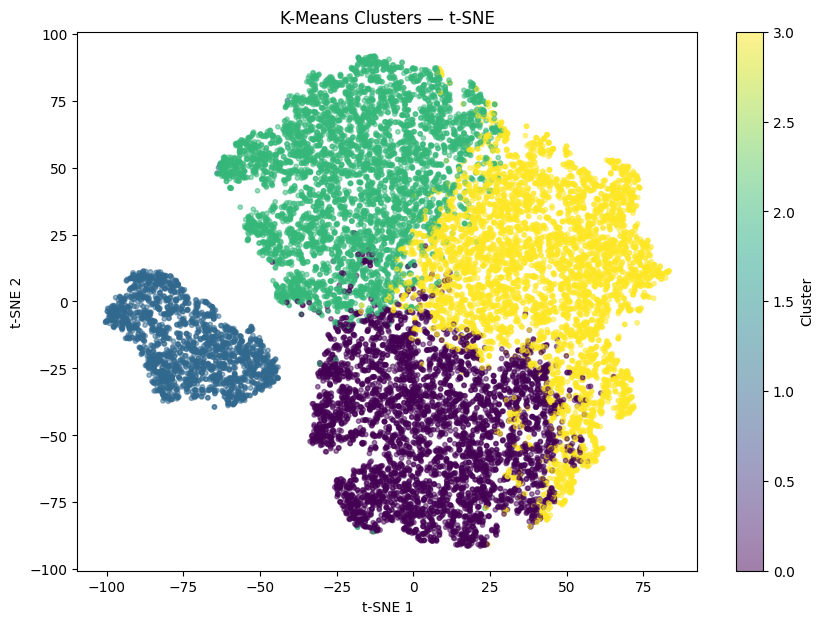

In [56]:
plt.figure(figsize=(10, 7))

plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=cluster_df["final_cluster"],
    s=10,
    alpha=0.5
)

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("K-Means Clusters — t-SNE")
plt.colorbar(label="Cluster")

plt.show()

In [57]:
import umap.umap_ as umap

# UMAP for visualization only
umap_model = umap.UMAP(
    n_components=2,
    n_neighbors=30,
    min_dist=0.1,
    metric="euclidean",
    random_state=42
)

X_umap = umap_model.fit_transform(X_pca_90)

print("UMAP shape:", X_umap.shape)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP shape: (17954, 2)


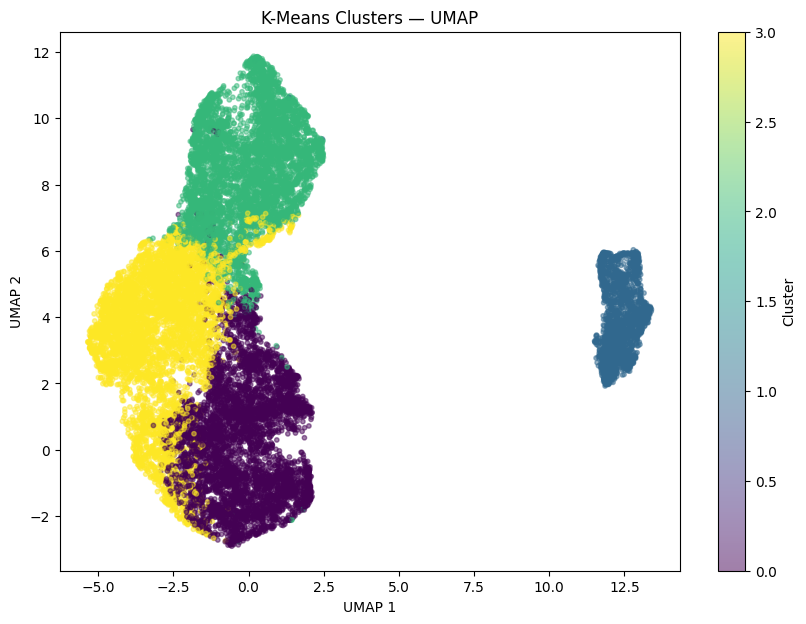

In [58]:
plt.figure(figsize=(10, 7))

plt.scatter(
    X_umap[:, 0],
    X_umap[:, 1],
    c=cluster_df["final_cluster"],
    s=10,
    alpha=0.5
)

plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("K-Means Clusters — UMAP")
plt.colorbar(label="Cluster")

plt.show()

In [59]:
# Key player-level variables
profile_cols = [
    "overall_rating",
    "potential",
    "age",
    "value_euro"
]

# Add all 29 football skill attributes
profile_cols += clustering_features

# Mean profile
cluster_profile = cluster_df.groupby("final_cluster")[profile_cols].mean()

# Cluster sizes
cluster_sizes = cluster_df["final_cluster"].value_counts().sort_index()

print("FINAL CLUSTER PROFILE")
print("=" * 70)

print("\nCluster Sizes:")
print(cluster_sizes)

print("\nMean Profile:")
display(cluster_profile.round(2))

FINAL CLUSTER PROFILE

Cluster Sizes:
final_cluster
0    5149
1    2071
2    5233
3    5501
Name: count, dtype: int64

Mean Profile:


,overall_rating,potential,age,value_euro,crossing,finishing,heading_accuracy,short_passing,volleys,dribbling,...,long_shots,aggression,interceptions,positioning,vision,penalties,composure,marking,standing_tackle,sliding_tackle
final_cluster,,,,,,,,,,,,,,,,,,,,,
0,64.06,70.89,23.98,1285677.22,52.29,60.50,52.66,59.80,53.17,64.35,...,55.81,47.45,28.89,60.94,56.73,57.56,58.01,32.77,30.17,28.42
1,64.45,69.81,26.44,1622327.59,14.26,11.92,14.37,27.16,12.28,13.77,...,12.46,26.26,16.94,11.14,37.12,19.90,44.47,15.02,14.16,14.06
2,63.68,69.88,24.79,1121676.36,45.11,31.84,59.43,57.08,32.02,48.75,...,35.05,63.61,60.99,39.84,43.54,40.75,54.98,61.10,64.06,62.05
3,71.39,74.02,27.45,5209719.82,64.97,56.63,58.96,70.64,54.69,68.63,...,62.65,67.37,60.84,63.59,65.81,57.70,68.17,59.48,61.28,58.25


In [60]:
# Mean standardized skill profile by cluster
cluster_zprofile = pd.DataFrame(
    X_scaled,
    columns=clustering_features
).assign(
    cluster=cluster_df["final_cluster"].values
).groupby("cluster").mean()

print("TOP ATTRIBUTES BY CLUSTER")
print("=" * 70)

for cluster in cluster_zprofile.index:
    print(f"\nCluster {cluster}")
    print("-" * 40)
    
    print(
        cluster_zprofile.loc[cluster]
        .sort_values(ascending=False)
        .head(8)
        .round(2)
    )

TOP ATTRIBUTES BY CLUSTER

Cluster 0
----------------------------------------
finishing       0.77
volleys         0.58
penalties       0.58
positioning     0.56
acceleration    0.52
sprint_speed    0.51
agility         0.48
dribbling       0.48
Name: 0, dtype: float64

Cluster 1
----------------------------------------
reactions        -0.35
strength         -0.38
jumping          -0.64
vision           -1.15
composure        -1.22
interceptions    -1.43
balance          -1.48
sliding_tackle   -1.49
Name: 1, dtype: float64

Cluster 2
----------------------------------------
sliding_tackle      0.77
standing_tackle     0.75
marking             0.70
interceptions       0.69
aggression          0.45
heading_accuracy    0.42
strength            0.37
jumping             0.21
Name: 2, dtype: float64

Cluster 3
----------------------------------------
long_passing         0.88
vision               0.88
curve                0.86
freekick_accuracy    0.86
crossing             0.83
composure   

In [61]:
print("LOWEST ATTRIBUTES BY CLUSTER")
print("=" * 70)

for cluster in cluster_zprofile.index:
    print(f"\nCluster {cluster}")
    print("-" * 40)
    
    print(
        cluster_zprofile.loc[cluster]
        .sort_values()
        .head(8)
        .round(2)
    )

LOWEST ATTRIBUTES BY CLUSTER

Cluster 0
----------------------------------------
interceptions     -0.86
sliding_tackle    -0.81
standing_tackle   -0.81
marking           -0.72
aggression        -0.48
strength          -0.44
reactions         -0.34
jumping           -0.23
Name: 0, dtype: float64

Cluster 1
----------------------------------------
ball_control       -2.27
dribbling          -2.17
heading_accuracy   -2.16
short_passing      -2.11
stamina            -2.07
positioning        -1.97
crossing           -1.92
shot_power         -1.89
Name: 1, dtype: float64

Cluster 2
----------------------------------------
vision              -0.70
finishing           -0.69
long_shots          -0.61
volleys             -0.60
curve               -0.52
positioning         -0.51
penalties           -0.48
freekick_accuracy   -0.47
Name: 2, dtype: float64

Cluster 3
----------------------------------------
strength            0.20
jumping             0.25
sprint_speed        0.35
acceleration    

In [62]:
from scipy.stats import kruskal
import scikit_posthocs as sp

# Extract overall rating for each final cluster
groups = [
    cluster_df.loc[
        cluster_df["final_cluster"] == cluster,
        "overall_rating"
    ]
    for cluster in sorted(cluster_df["final_cluster"].unique())
]

# Kruskal-Wallis test
kw_stat, kw_p = kruskal(*groups)

print("Kruskal-Wallis Test")
print("=" * 45)
print(f"Statistic: {kw_stat:.4f}")
print(f"p-value:   {kw_p:.4e}")

Kruskal-Wallis Test
Statistic: 4536.9518
p-value:   0.0000e+00


In [63]:
# Dunn's post-hoc test with Bonferroni correction
dunn_results = sp.posthoc_dunn(
    cluster_df,
    val_col="overall_rating",
    group_col="final_cluster",
    p_adjust="bonferroni"
)

print("\nDunn's Post-hoc Test (Bonferroni corrected)")
print("=" * 55)

display(dunn_results)


Dunn's Post-hoc Test (Bonferroni corrected)


,0,1,2,3
0,1.000000,0.039504,0.020444,0.0
1,0.039504,1.000000,0.000005,0.0
2,0.020444,0.000005,1.000000,0.0
3,0.000000,0.000000,0.000000,1.0


In [64]:
# Final cluster summary

cluster_summary = cluster_df.groupby("final_cluster").agg(
    players=("final_cluster", "size"),
    avg_rating=("overall_rating", "mean"),
    avg_potential=("potential", "mean"),
    avg_age=("age", "mean"),
    avg_value=("value_euro", "mean")
)

# Percentage of total players
cluster_summary["percentage"] = (
    cluster_summary["players"] / len(cluster_df) * 100
)

# Add interpretable cluster names
cluster_names = {
    0: "Attacking Players",
    1: "Goalkeepers",
    2: "Defensive Players",
    3: "Elite / Playmaking Players"
}

cluster_summary["cluster_name"] = (
    cluster_summary.index.map(cluster_names)
)

# Reorder columns
cluster_summary = cluster_summary[
    [
        "cluster_name",
        "players",
        "percentage",
        "avg_rating",
        "avg_potential",
        "avg_age",
        "avg_value"
    ]
]

# Round
cluster_summary = cluster_summary.round({
    "percentage": 2,
    "avg_rating": 2,
    "avg_potential": 2,
    "avg_age": 2,
    "avg_value": 0
})

display(cluster_summary)

,cluster_name,players,percentage,avg_rating,avg_potential,avg_age,avg_value
final_cluster,,,,,,,
0,Attacking Players,5149,28.68,64.06,70.89,23.98,1285677.0
1,Goalkeepers,2071,11.54,64.45,69.81,26.44,1622328.0
2,Defensive Players,5233,29.15,63.68,69.88,24.79,1121676.0
3,Elite / Playmaking Players,5501,30.64,71.39,74.02,27.45,5209720.0


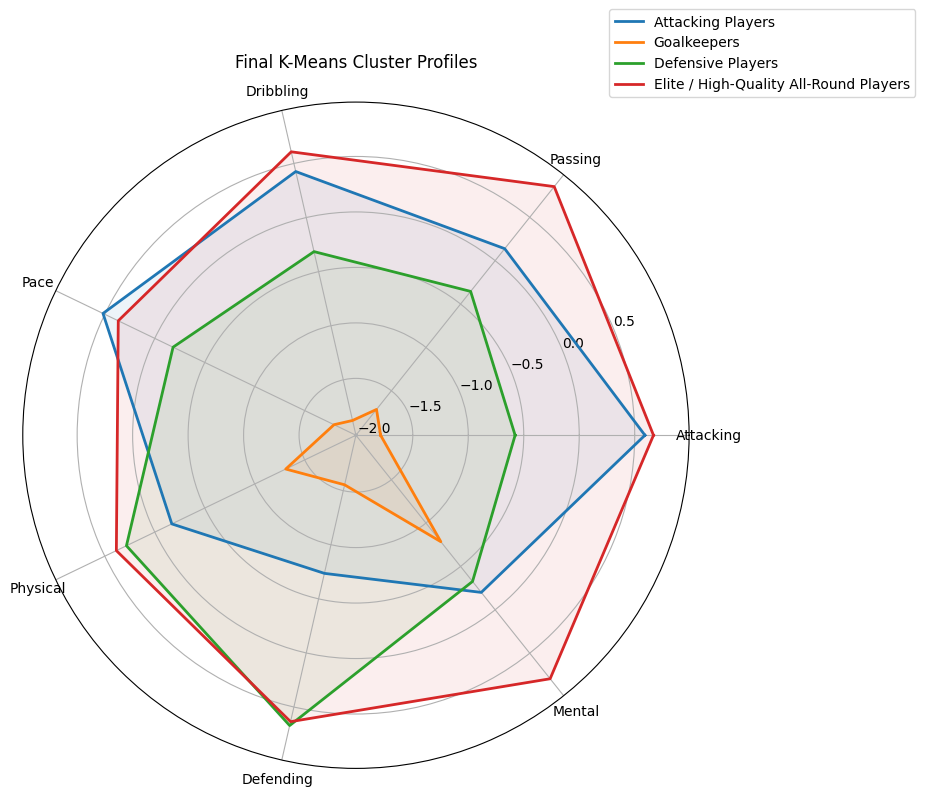

Radar-chart dimension scores:


,Attacking,Passing,Dribbling,Pace,Physical,Defending,Mental
cluster,,,,,,,
0,0.59,0.14,0.43,0.52,-0.17,-0.74,-0.20
1,-1.79,-1.71,-1.88,-1.79,-1.31,-1.55,-0.79
2,-0.58,-0.35,-0.31,-0.18,0.28,0.67,-0.33
3,0.67,0.85,0.61,0.36,0.38,0.64,0.79


In [65]:
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Create standardized skill dataframe
X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=clustering_features
)

X_scaled_df["cluster"] = cluster_df["final_cluster"].values

# Mean standardized profile by cluster
cluster_zprofile = X_scaled_df.groupby("cluster").mean()

# Group attributes into meaningful football dimensions
skill_groups = {
    "Attacking": [
        "finishing", "volleys", "long_shots", "positioning", "penalties"
    ],
    "Passing": [
        "short_passing", "long_passing", "vision",
        "crossing", "curve", "freekick_accuracy"
    ],
    "Dribbling": [
        "dribbling", "ball_control", "agility", "balance"
    ],
    "Pace": [
        "acceleration", "sprint_speed"
    ],
    "Physical": [
        "strength", "stamina", "jumping", "heading_accuracy"
    ],
    "Defending": [
        "interceptions", "marking",
        "standing_tackle", "sliding_tackle", "aggression"
    ],
    "Mental": [
        "reactions", "composure"
    ]
}

# Calculate dimension-level standardized scores
radar_data = pd.DataFrame(index=cluster_zprofile.index)

for group, features in skill_groups.items():
    radar_data[group] = cluster_zprofile[features].mean(axis=1)

# Radar chart
categories = radar_data.columns.tolist()
angles = np.linspace(
    0, 2 * np.pi, len(categories), endpoint=False
)
angles = np.concatenate([angles, [angles[0]]])

cluster_names = {
    0: "Attacking Players",
    1: "Goalkeepers",
    2: "Defensive Players",
    3: "Elite / High-Quality All-Round Players"
}

plt.figure(figsize=(10, 8))
ax = plt.subplot(111, polar=True)

for cluster in radar_data.index:
    values = radar_data.loc[cluster].values
    values = np.concatenate([values, [values[0]]])

    ax.plot(
        angles,
        values,
        linewidth=2,
        label=cluster_names[cluster]
    )
    ax.fill(
        angles,
        values,
        alpha=0.08
    )

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)

ax.set_title(
    "Final K-Means Cluster Profiles",
    pad=25
)

ax.legend(
    loc="upper right",
    bbox_to_anchor=(1.35, 1.15)
)

plt.tight_layout()
plt.show()

print("Radar-chart dimension scores:")
display(radar_data.round(2))